<a href="https://colab.research.google.com/github/Adesaputra4006/PJBL_AnReg/blob/main/Uas_Anreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nama: Ade saputra
# NIM : 2430109040006
# Matkul : Analisis Regresi

## **Load dan Pembersihan Data**

   waktu  jumlah_hotspot  curah_hujan       suhu  kelembaban  kecepatan_angin  \
0      0      597.659528   150.142143  31.871988   66.618519         4.713152   
1      1      332.132859   155.496279  33.978028   67.183618         6.268954   
2      2      265.806173   202.991035  32.619268   67.192709         4.983400   
3      3      240.416902   279.676836  33.256310   67.819487         4.640057   
4      4      246.651532   202.393513  31.028269   67.403307         5.144500   

   luas_gambut  aktivitas_manusia  
0  5679.605184          -1.027391  
1  7370.885127           0.971875  
2  6037.848211           0.335190  
3  6548.807751          -0.379968  
4  2495.660168          -0.441833  

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   waktu              200 non-null    int64  
 1   jumlah_hotspot     200

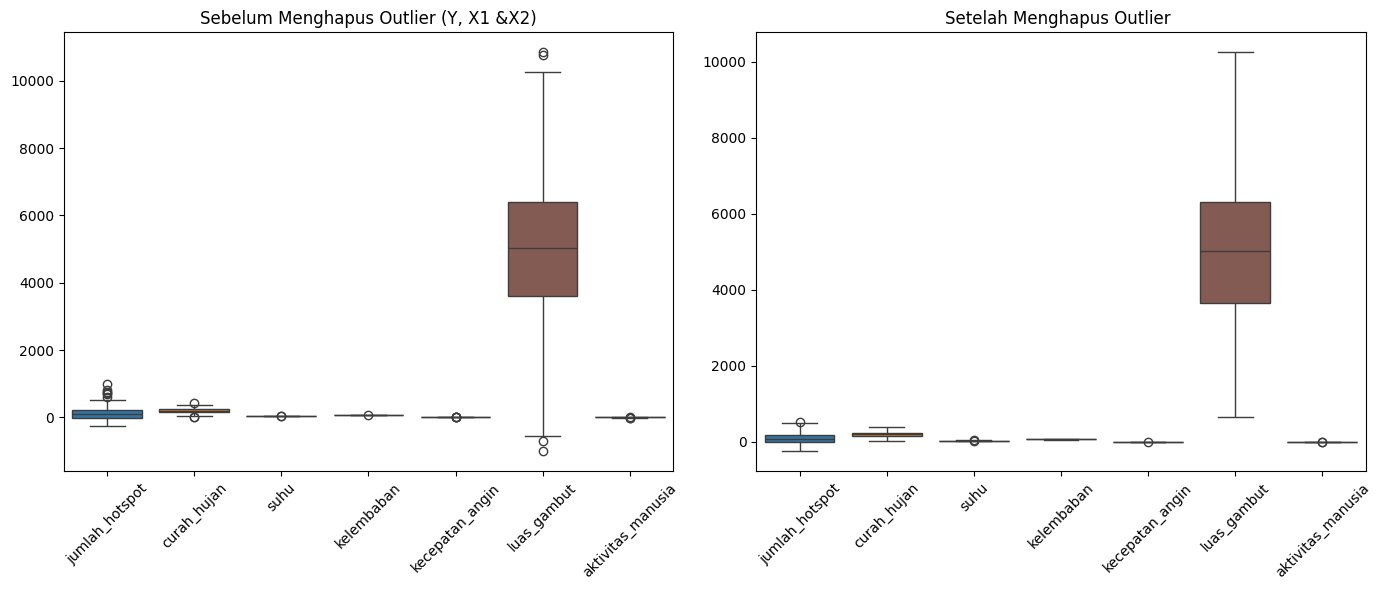


Data berhasil dibersihkan.


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("karhutla_314.csv")

# Menampilkan 5 data pertama
print(df.head())

# Informasi dataset
print("\n=== INFO DATASET ===")
print(df.info())

# Statistik deskriptif
print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

# =========================
# CEK MISSING VALUE
# =========================

print("\n=== MISSING VALUE ===")
print(df.isnull().sum())

# Total missing value
print("\nTotal Missing Value:")
print(df.isnull().sum().sum())

# Mengisi missing value numerik dengan median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# =========================
# CEK DATA DUPLIKAT
# =========================

print("\n=== DATA DUPLIKAT ===")
print("Jumlah data duplikat:", df.duplicated().sum())

# Menghapus data duplikat
df = df.drop_duplicates()

# =========================
# MENENTUKAN VARIABEL
# =========================

selected_cols = [
    "jumlah_hotspot",
    "curah_hujan",
    "suhu",
    "kelembaban",
    "kecepatan_angin",
    "luas_gambut",
    "aktivitas_manusia"
]

# =========================
# DETEKSI OUTLIER
# =========================

print("\n=== JUMLAH OUTLIER ===")

for col in selected_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outlier)}")


# Boxplot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def remove_outliers_iqr(df_param, columns):
    df_clean = df_param.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)  # Kuartil pertama (Q1)
        Q3 = df_clean[col].quantile(0.75)  # Kuartil ketiga (Q3)
        IQR = Q3 - Q1  # Interquartile Range (IQR)

        lower_bound = Q1 - 1.5 * IQR  # Batas bawah
        upper_bound = Q3 + 1.5 * IQR  # Batas atas

        # Hanya mempertahankan data yang berada dalam batas IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

# Membersihkan data dari outlier (menggunakan semua kolom numerik untuk proses pembersihan)
numeric_cols_all = df.select_dtypes(include=[np.number]).columns
cleaned_data = remove_outliers_iqr(df, numeric_cols_all)

# Membuat Boxplot sebelum dan sesudah menghapus outlier untuk kolom yang dipilih
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot sebelum pembersihan
sns.boxplot(data=df[selected_cols], ax=axes[0])
axes[0].set_title("Sebelum Menghapus Outlier (Y, X1 &X2)")
axes[0].set_xticks(range(len(selected_cols)))
axes[0].set_xticklabels(selected_cols, rotation=45)

# Boxplot setelah pembersihan
sns.boxplot(data=cleaned_data[selected_cols], ax=axes[1])
axes[1].set_title("Setelah Menghapus Outlier ")
axes[1].set_xticks(range(len(selected_cols)))
axes[1].set_xticklabels(selected_cols, rotation=45)

plt.tight_layout()
plt.show()

print("\nData berhasil dibersihkan.")


**Interpretasi**

Dataset yang digunakan terdiri dari 200 observasi dengan 8 variabel yang seluruhnya bertipe numerik sehingga dapat digunakan dalam analisis regresi linear berganda. Hasil pemeriksaan missing value menunjukkan bahwa tidak terdapat data kosong pada dataset, sedangkan pemeriksaan data duplikat menunjukkan tidak terdapat data yang berulang. Selain itu, deteksi outlier menggunakan metode Interquartile Range (IQR) menunjukkan adanya beberapa outlier pada variabel jumlah_hotspot, curah_hujan, suhu, kelembaban, kecepatan_angin, luas_gambut, dan aktivitas_manusia. Outlier yang terdeteksi kemudian dihapus agar data menjadi lebih stabil dan tidak terlalu mempengaruhi hasil analisis regresi.


## **Standarisasi (Z-Score)**

Z-score (standard score) adalah teknik dalam statistik untuk menstandarisasi data sehingga memiliki rata-rata 0 dan standar deviasi 1. Hal ini dilakukan karena sebagian variabel memiliki rentang yang jauh dari variabel lainnya

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import zscore # Import zscore

# Memilih hanya kolom numerik dari cleaned_data untuk standarisasi
# Ini memastikan bahwa kita hanya menstandarisasi data yang sudah bersih dari outlier
numeric_cols_for_zscore = cleaned_data.select_dtypes(include=[np.number]).columns

# Membuat salinan cleaned_data untuk menyimpan hasil z-score
standar = cleaned_data.copy()

# Menerapkan Z-Score ke kolom numerik pada 'standar'
standar[numeric_cols_for_zscore] = cleaned_data[numeric_cols_for_zscore].apply(zscore)

# Menampilkan hasil
print(standar.head())

      waktu  jumlah_hotspot  curah_hujan      suhu  kelembaban  \
1 -1.708832        1.650144    -0.599190  0.969594   -0.288415   
2 -1.691504        1.187095     0.075214  0.259072   -0.284202   
3 -1.674176        1.009844     1.164117  0.592194    0.006237   
4 -1.656848        1.053370     0.066729 -0.572892   -0.186614   
5 -1.639520        0.810133     0.428142 -1.444545    1.694235   

   kecepatan_angin  luas_gambut  aktivitas_manusia  
1         0.837607     1.235878           1.127219  
2        -0.168898     0.524679           0.463548  
3        -0.437713     0.797285          -0.281922  
4        -0.042767    -1.365141          -0.346409  
5         0.374008    -0.103328          -0.168324  


## **Pembuatan Model Utama**

In [24]:
import statsmodels.api as sm

# Variabel dependen
y = standar["jumlah_hotspot"]

# Variabel independen
X = standar[[
    "curah_hujan",
    "suhu",
    "kelembaban",
    "kecepatan_angin",
    "luas_gambut",
    "aktivitas_manusia"
]]

# Menambahkan konstanta
X_sm = sm.add_constant(X)

# Membentuk model regresi linear berganda
model = sm.OLS(y, X_sm).fit()

# Menampilkan ringkasan model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         jumlah_hotspot   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.5206
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.792
Time:                        05:45:44   Log-Likelihood:                -249.54
No. Observations:                 177   AIC:                             513.1
Df Residuals:                     170   BIC:                             535.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -7.697e-17      0.07

**Interpretasi**
Hasil OLS menunjukan hasil sebagai berikut:

1. nilai R²= 0.018, artinya 1.8% variasi jumlah hotspot dijelaskan oleh variabel independen

2. Seluruh variabel independen memiliki nilai p-value lebih besar dari 0,05, sehingga secara parsial tidak terdapat variabel yang berpengaruh signifikan terhadap jumlah_hotspot.

Oleh karena itu, model awal ini masih kurang baik dan perlu dilakukan
evaluasi lanjutan, seperti pengujian asumsi klasik, transformasi data, maupun seleksi model untuk memperoleh model regresi yang lebih optimal.

### **Interpretasi koefisien**

In [25]:
# =========================
# INTERPRETASI KOEFISIEN
# =========================

print("\n=== INTERPRETASI KOEFISIEN REGRESI ===")

for variabel, nilai in model.params.items():

    if variabel == "const":

        print(
            f"Konstanta sebesar {nilai:.4f} menunjukkan bahwa "
            f"jika seluruh variabel independen bernilai 0, "
            f"maka jumlah_hotspot diperkirakan sebesar {nilai:.4f}."
        )

    elif nilai > 0:

        print(
            f"Koefisien variabel {variabel} bernilai positif sebesar {nilai:.4f}. "
            f"Artinya, setiap kenaikan 1 satuan pada variabel {variabel} "
            f"akan meningkatkan jumlah_hotspot sebesar {nilai:.4f}, "
            f"dengan asumsi variabel independen lainnya konstan."
        )

    else:

        print(
            f"Koefisien variabel {variabel} bernilai negatif sebesar {nilai:.4f}. "
            f"Artinya, setiap kenaikan 1 satuan pada variabel {variabel} "
            f"akan menurunkan jumlah_hotspot sebesar {abs(nilai):.4f}, "
            f"dengan asumsi variabel independen lainnya konstan."
        )


=== INTERPRETASI KOEFISIEN REGRESI ===
Konstanta sebesar -0.0000 menunjukkan bahwa jika seluruh variabel independen bernilai 0, maka jumlah_hotspot diperkirakan sebesar -0.0000.
Koefisien variabel curah_hujan bernilai negatif sebesar -0.0038. Artinya, setiap kenaikan 1 satuan pada variabel curah_hujan akan menurunkan jumlah_hotspot sebesar 0.0038, dengan asumsi variabel independen lainnya konstan.
Koefisien variabel suhu bernilai positif sebesar 0.1359. Artinya, setiap kenaikan 1 satuan pada variabel suhu akan meningkatkan jumlah_hotspot sebesar 0.1359, dengan asumsi variabel independen lainnya konstan.
Koefisien variabel kelembaban bernilai positif sebesar 0.0128. Artinya, setiap kenaikan 1 satuan pada variabel kelembaban akan meningkatkan jumlah_hotspot sebesar 0.0128, dengan asumsi variabel independen lainnya konstan.
Koefisien variabel kecepatan_angin bernilai positif sebesar 0.0136. Artinya, setiap kenaikan 1 satuan pada variabel kecepatan_angin akan meningkatkan jumlah_hotspot s

**Korelasi Variabel Independen**

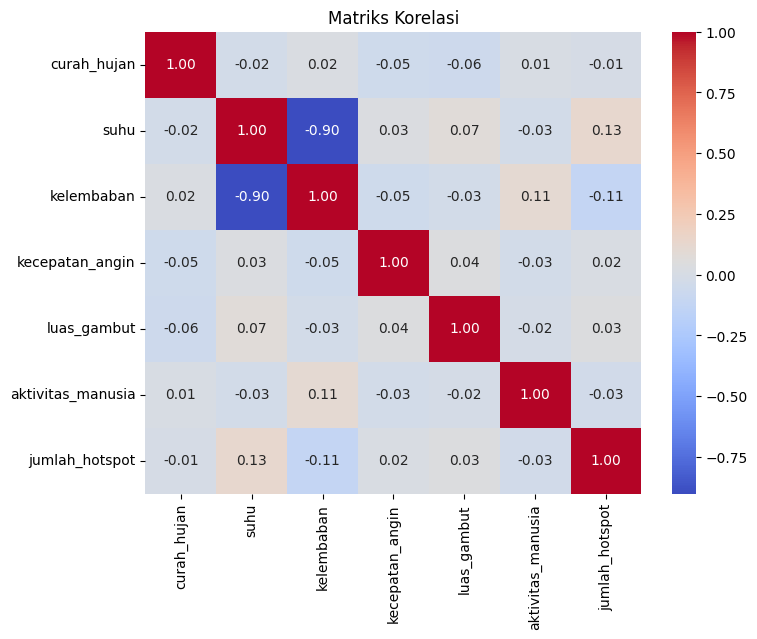

In [26]:
plt.figure(figsize=(8, 6))
combined_df = pd.concat([X, y], axis=1)
sns.heatmap(combined_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()

**Interpretasi**


1. Suhu vs Kelembaban (-0.90) → Korelasi negatif sangat kuat, artinya ketika suhu meningkat maka kelembaban cenderung menurun. Hubungan yang sangat kuat ini mengindikasikan adanya multikolinearitas antara kedua variabel.

2. Suhu vs Jumlah Hotspot (0.13) → Korelasi positif sangat lemah, menunjukkan bahwa peningkatan suhu hanya memiliki hubungan kecil terhadap jumlah hotspot.

3. Kelembaban vs Jumlah Hotspot (-0.11) → Korelasi negatif sangat lemah, yang menunjukkan bahwa peningkatan kelembaban cenderung sedikit menurunkan jumlah hotspot.

4. Curah Hujan, Kecepatan Angin, Luas Gambut, dan Aktivitas Manusia terhadap Jumlah Hotspot → Seluruh variabel memiliki nilai korelasi yang mendekati 0 sehingga hubungan antar variabel dengan jumlah hotspot tergolong lemah.

5. Kesimpulan:
Sebagian besar variabel pada dataset memiliki hubungan yang lemah terhadap jumlah hotspot. Namun, variabel suhu dan kelembaban memiliki korelasi negatif yang sangat kuat sehingga menyebabkan terjadinya multikolinearitas pada model regresi.



##**Evaluasi Performa Awal**

### **R Squared dan RMSE**

In [27]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Melakukan prediksi menggunakan model
prediksi = model.predict(X_sm)

# Menghitung R²
r2 = r2_score(y, prediksi)

# Menghitung RMSE
rmse = np.sqrt(mean_squared_error(y, prediksi))

# Menampilkan hasil
print("R² :", r2)
print("RMSE :", rmse)

R² : 0.01804129306756752
RMSE : 0.9909382962285961


**Interpretasi**

1. R² : 0.0180 → Nilai R² menunjukkan bahwa model regresi hanya mampu menjelaskan sekitar 1,8% variasi jumlah hotspot, sedangkan sisanya dipengaruhi oleh faktor lain di luar model.

2. RMSE : 0.9909 → Nilai RMSE menunjukkan rata-rata kesalahan prediksi model terhadap data. Nilai ini menunjukkan bahwa model masih memiliki tingkat error yang cukup besar sehingga performa model regresi awal masih belum optimal.

Kesimpulan:
Model regresi awal masih memiliki kemampuan prediksi yang rendah sehingga diperlukan perbaikan model melalui transformasi data dan seleksi variabel.


### **Uji Signifikansi**

Uji t digunakan untuk mengetahui apakah masing-masing variabel independen berpengaruh signifikan terhadap jumlah_hotspot secara individual. Sedangkan uji F digunakan untuk mengetahui apakah seluruh variabel independen secara bersama-sama berpengaruh signifikan terhadap jumlah_hotspot.

1. Untuk uji t:
  - Jika p-value < 0,05 → variabel signifikan
  - Jika p-value > 0,05 → variabel tidak signifikan
2. Untuk uji f
  - Jika Prob(F-statistic) < 0,05 → model signifikan
  - Jika Prob(F-statistic) > 0,05 → model tidak signifikan


In [37]:
# =========================
# UJI t
# =========================

print("=== UJI t ===")

print(model.pvalues)

# =========================
# UJI F
# =========================

print("\n=== UJI F ===")

print("F-statistic :", model.fvalue)

print("Prob(F-statistic) :", model.f_pvalue)

=== UJI t ===
const                1.523593e-08
curah_hujan          9.798264e-01
kecepatan_angin      7.363971e-01
luas_gambut          4.669070e-01
aktivitas_manusia    8.895060e-01
dtype: float64

=== UJI F ===
F-statistic : 0.1738578298367681
Prob(F-statistic) : 0.951569024624149



**Interpretasi Uji t dan Uji F**

1. Uji t menunjukkan bahwa seluruh variabel independen memiliki nilai p-value lebih besar dari 0,05, yaitu curah_hujan sebesar 0.9798, kecepatan_angin sebesar 0.7364, luas_gambut sebesar 0.4669, dan aktivitas_manusia sebesar 0.8895. Hal ini menunjukkan bahwa secara parsial seluruh variabel independen tidak berpengaruh signifikan terhadap jumlah hotspot.

2. Uji F menunjukkan nilai Prob(F-statistic) sebesar 0.9516 yang lebih besar dari 0,05. Hal ini menunjukkan bahwa secara simultan seluruh variabel independen dalam model belum berpengaruh signifikan terhadap jumlah hotspot.

Kesimpulan:
Model regresi yang dibentuk masih belum mampu menjelaskan hubungan antara variabel independen terhadap jumlah hotspot dengan baik.

##**Uji Asumsi Klasik**

### **Multikolinearita**s

Variance Inflation Factor (VIF) adalah metode statistik yang digunakan untuk mendeteksi multikolinearitas(memiliki hubungan yang sangat kuat) dalam analisis regresi linear. Multikolinearitas terjadi ketika dua atau lebih variabel independen dalam model regresi memiliki korelasi(hubungan antara dua variabel) yang sangat tinggi, yang dapat menyebabkan masalah dalam interpretasi hasil regresi.

**Interpretasi Hasil :**

*   VIF < 5 → Tidak ada masalah multikolinearitas
*   5 ≤ VIF ≤ 10 → Ada indikasi multikolinearitas, perlu diperiksa lebih lanjut
*   VIF > 10 → Multikolinearitas tinggi, sebaiknya diperbaiki (misalnya, dengan menghapus variabel yang berkorelasi tinggi).


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Membuat dataframe VIF
vif = pd.DataFrame()

# Nama variabel
vif["Variabel"] = X.columns

# Menghitung VIF
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Menampilkan hasil
print(vif)

            Variabel       VIF
0        curah_hujan  1.006746
1               suhu  5.510386
2         kelembaban  5.552693
3    kecepatan_angin  1.007633
4        luas_gambut  1.018265
5  aktivitas_manusia  1.038395


**Interpretasi**
Hasil uji multikolinieritas menunjukkan bahwa sebagian besar variabel independen memiliki nilai VIF lebih besar dari 5, sehingga terdapat masalah multikolinieritas pada model regresi.

### **Heteroskedastisitas**

**Heteroskedastisitas** adalah kebalikan dari homoskedastisitas, yaitu keadaan dimana terjadinya ketidaksamaan varian dari error untuk semua pengamatan setiap variabel bebas pada model regresi. Sebaliknya, pengertian homoskedastisitas adalah keadaan dimana adanya kesamaan varian dari error untuk semua pengamatan setiap variabel bebas pada model regresi.

Syarat Hetero:
1. p-value > 0,05 → tidak terjadi heteroskedastisitas
2. p-value < 0,05 → terjadi heteroskedastisitas

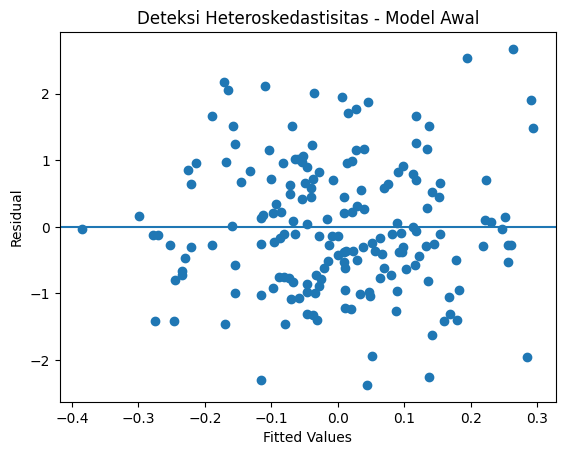

LM Stat : 9.319371308547485
p-value : 0.1563974455693169


In [30]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan

plt.figure()

plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0)

plt.title('Deteksi Heteroskedastisitas - Model Awal')
plt.xlabel('Fitted Values')
plt.ylabel('Residual')

plt.show()

residual = model.resid

bp_test = het_breuschpagan(residual, model.model.exog)

print("LM Stat :", bp_test[0])
print("p-value :", bp_test[1])

**Interpretasi**
Karena p-value model awal > 0.05 maka dapat disimpulkan bahwa tidak terjadi heterokedastisitas

###**Autokorelaas**i

Uji autokorelasi digunakan untuk mengetahui apakah residual pada model regresi saling berkorelasi antar observasi, deteksi autokorelasi dilakukan menggunakan uji Durbin-Watson.

Interpretasi:
1. dw ≈ 2 : tidak ada autokorelasi
2. dw < 1.5 : ada autokorelasi positif
3. dw > 2.5 : ada aotokorelasi negatif


=== Durbin–Watson Test ===
Nilai Durbin–Watson: 0.6731081274288905
Interpretasi: Ada autokorelasi positif.


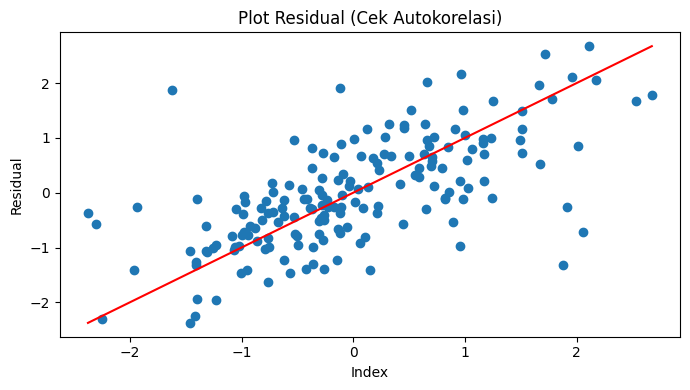

In [31]:
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ambil residual dari model
residual = model.resid

# Uji Durbin-Watson
dw = durbin_watson(residual)

print("\n=== Durbin–Watson Test ===")
print("Nilai Durbin–Watson:", dw)

# Interpretasi otomatis
if 1.5 <= dw <= 2:
    print("Interpretasi: Tidak ada autokorelasi.")
elif dw < 1.5:
    print("Interpretasi: Ada autokorelasi positif.")
else:
    print("Interpretasi: Ada autokorelasi negatif.")

# Plot residual
plt.figure(figsize=(7,4))
pd.plotting.lag_plot(pd.Series(residual))
x = np.linspace(min(residual), max(residual), 100)
plt.plot(x, x, linestyle='-', color='red')
plt.title("Plot Residual (Cek Autokorelasi)")
plt.xlabel("Index")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

**Interpretaasi**
Nilai Durbin-Watson sebesar 0,673 berada jauh di bawah 2, sehingga menunjukkan adanya autokorelasi positif pada residual model regresi.
Hal ini menunjukkan bahwa residual pada suatu observasi berkorelasi dengan residual observasi lainnya, sehingga asumsi independensi residual tidak terpenuhi.


## **Optimalisasi dan Validasi Model**

### **Transformasi Data**

Pada tahap ini dilakukan transformasi data menggunakan transformasi logaritma natural (ln). Transformasi log digunakan untuk mengurangi penyebaran data yang terlalu besar, memperbaiki distribusi data, serta membantu mengurangi masalah heteroskedastisitas pada model regresi.

In [32]:
import numpy as np

# Membuat dataframe baru hanya dengan variabel yang digunakan
transform = standar[[
    "jumlah_hotspot",
    "curah_hujan",
    "kecepatan_angin",
    "luas_gambut",
    "aktivitas_manusia"
]].copy()

# Transformasi log pada variabel dependen
transform["jumlah_hotspot"] = np.log1p(
    transform["jumlah_hotspot"] - transform["jumlah_hotspot"].min() + 1
)

# Transformasi log pada variabel independen
transform["curah_hujan"] = np.log1p(
    transform["curah_hujan"] - transform["curah_hujan"].min() + 1
)

transform["kecepatan_angin"] = np.log1p(
    transform["kecepatan_angin"] - transform["kecepatan_angin"].min() + 1
)

transform["luas_gambut"] = np.log1p(
    transform["luas_gambut"] - transform["luas_gambut"].min() + 1
)

transform["aktivitas_manusia"] = np.log1p(
    transform["aktivitas_manusia"] - transform["aktivitas_manusia"].min() + 1
)

# Menampilkan hasil transformasi
print(transform.head())

   jumlah_hotspot  curah_hujan  kecepatan_angin  luas_gambut  \
1        1.802845     1.312651         1.721397     1.720302   
2        1.723450     1.479424         1.522971     1.584124   
3        1.691309     1.700981         1.462564     1.638535   
4        1.699298     1.477489         1.550104     1.093666   
5        1.653813     1.556742         1.634859     1.446215   

   aktivitas_manusia  
1           1.765479  
2           1.644940  
3           1.489580  
4           1.474933  
5           1.514870  




### **Seleksi Model**

Setelah dilakukan transformasi data, tahap selanjutnya adalah seleksi model untuk memperoleh kombinasi variabel independen terbaik dalam membentuk model regresi linear berganda. Seleksi model dilakukan dengan membentuk seluruh kemungkinan kombinasi variabel independen, kemudian setiap kombinasi dievaluasi menggunakan nilai koefisien determinasi (R^2 ) dan Root Mean Squared Error (RMSE).

In [33]:
import itertools
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import mean_squared_error

# Variabel independen
predictors = [
    "curah_hujan",
    "kecepatan_angin",
    "luas_gambut",
    "aktivitas_manusia"
]

# Variabel dependen
y = transform["jumlah_hotspot"]

# Menyimpan hasil model
hasil_model = []

# Membuat semua kombinasi variabel
for k in range(1, len(predictors)+1):

    for combo in itertools.combinations(predictors, k):

        # Variabel X
        X = transform[list(combo)]

        # Tambahkan konstanta
        X = sm.add_constant(X)

        # Membentuk model regresi
        model = sm.OLS(y, X).fit()

        # Prediksi
        pred = model.predict(X)

        # Menghitung RMSE
        rmse = np.sqrt(mean_squared_error(y, pred))

        # Menyimpan hasil
        hasil_model.append({
            "Kombinasi Variabel": combo,
            "R_squared": model.rsquared,
            "Adj_R_squared": model.rsquared_adj,
            "RMSE": rmse
        })

# Mengubah menjadi dataframe
hasil_model = pd.DataFrame(hasil_model)

# Mengurutkan model terbaik
hasil_model = hasil_model.sort_values(
    by=["R_squared", "RMSE"],
    ascending=[False, True]
)

# Reset index
hasil_model = hasil_model.reset_index(drop=True)

# Menampilkan 10 model terbaik
print("=== 10 MODEL TERBAIK ===")
print(hasil_model.head(10))

# Mengambil model terbaik
best_model = hasil_model.iloc[0]

print("\n=== INTERPRETASI MODEL TERBAIK ===")
print(f"Kombinasi variabel terbaik : {best_model['Kombinasi Variabel']}")
print(f"R²                        : {best_model['R_squared']:.4f}")
print(f"Adjusted R²               : {best_model['Adj_R_squared']:.4f}")
print(f"RMSE                      : {best_model['RMSE']:.4f}")

print("\nInterpretasi:")
print(
    "Model dengan kombinasi variabel tersebut dipilih sebagai model terbaik "
    "karena memiliki nilai R² paling besar dan RMSE paling kecil dibandingkan "
    "kombinasi model lainnya."
)

=== 10 MODEL TERBAIK ===
                                  Kombinasi Variabel  R_squared  \
0  (curah_hujan, kecepatan_angin, luas_gambut, ak...   0.004027   
1  (kecepatan_angin, luas_gambut, aktivitas_manusia)   0.004023   
2        (curah_hujan, kecepatan_angin, luas_gambut)   0.003915   
3                     (kecepatan_angin, luas_gambut)   0.003911   
4      (curah_hujan, luas_gambut, aktivitas_manusia)   0.003369   
5                   (luas_gambut, aktivitas_manusia)   0.003358   
6                         (curah_hujan, luas_gambut)   0.003260   
7                                     (luas_gambut,)   0.003249   
8  (curah_hujan, kecepatan_angin, aktivitas_manusia)   0.000948   
9               (kecepatan_angin, aktivitas_manusia)   0.000923   

   Adj_R_squared      RMSE  
0      -0.019135  0.232657  
1      -0.013248  0.232658  
2      -0.013358  0.232670  
3      -0.007538  0.232671  
4      -0.013914  0.232734  
5      -0.008098  0.232735  
6      -0.008197  0.232747  
7    

###** Pembuatan Model Pada Kombinasi Variabel Terbaik**

In [34]:
import statsmodels.api as sm
import pandas as pd

# Variabel terbaik hasil seleksi model
best_vars = [
    "curah_hujan",
    "kecepatan_angin",
    "luas_gambut",
    "aktivitas_manusia"
]

# Variabel independen
X_final = transform[best_vars]

# Variabel dependen
y_final = transform["jumlah_hotspot"]

# Menambahkan konstanta
X_final = sm.add_constant(X_final)

# Membentuk model regresi final
model_final = sm.OLS(y_final, X_final).fit()

# Menampilkan ringkasan model
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:         jumlah_hotspot   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                    0.1739
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.952
Time:                        05:45:45   Log-Likelihood:                 6.9472
No. Observations:                 177   AIC:                            -3.894
Df Residuals:                     172   BIC:                             11.99
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.3584      0.22

1. Nilai R² menurun menjadi 0,0309, sehingga kemampuan model dalam menjelaskan jumlah_hotspot masih rendah.
2. Nilai RMSE sebesar 0.2327 menunjukkan rata-rata error prediksi model setelah transformasi.
3. Seluruh variabel independen masih memiliki p-value > 0,05, sehingga belum berpengaruh signifikan terhadap jumlah_hotspot.
4. Nilai Prob(F-statistic) sebesar 0.952 > 0,05 menunjukkan bahwa model secara simultan masih belum signifikan.

### **Uji Asumsi Klasik Pada Model Terbaik**

=== UJI ASUMSI KLASIK MODEL FINAL ===

=== UJI MULTIKOLINIERITAS ===
            Variabel       VIF
1        curah_hujan  1.006232
2    kecepatan_angin  1.005995
3        luas_gambut  1.006723
4  aktivitas_manusia  1.000539

=== UJI HETEROSKEDASTISITAS ===
LM Statistic: 6.7478
LM-Test p-value: 0.1498
F-Statistic: 1.7043
F-Test p-value: 0.1512


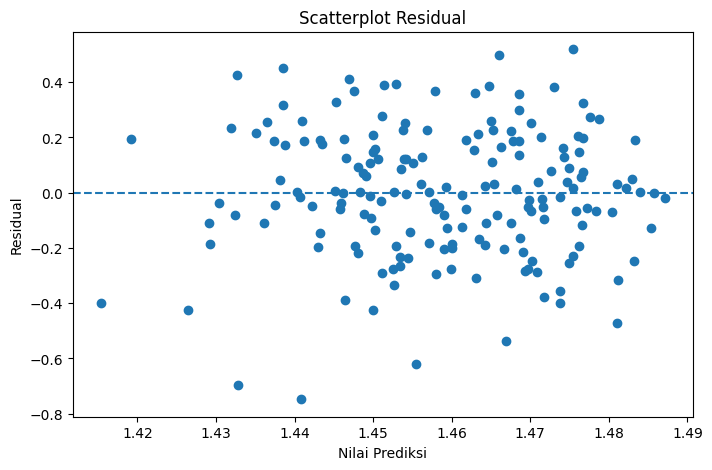


=== UJI AUTOKORELASI ===
Durbin-Watson : 0.6976


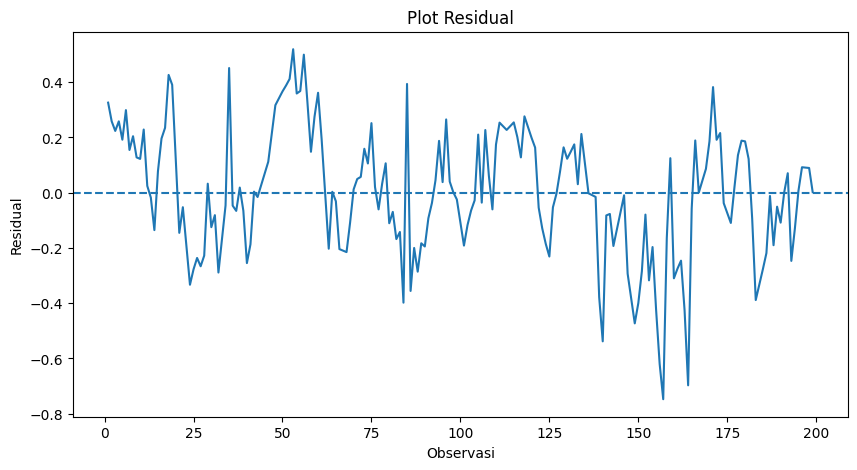

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import pandas as pd
import matplotlib.pyplot as plt

print("=== UJI ASUMSI KLASIK MODEL FINAL ===\n")

# ==================================================
# UJI MULTIKOLINIERITAS
# ==================================================

vif_data = pd.DataFrame()

vif_data["Variabel"] = X_final.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_final.values, i)
    for i in range(X_final.shape[1])
]

# Menghapus konstanta
vif_data = vif_data[vif_data["Variabel"] != "const"]

print("=== UJI MULTIKOLINIERITAS ===")
print(vif_data)


# ==================================================
# UJI HETEROSKEDASTISITAS
# ==================================================

bp_test = het_breuschpagan(
    model_final.resid,
    X_final
)

bp_labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

print("\n=== UJI HETEROSKEDASTISITAS ===")

for name, value in zip(bp_labels, bp_test):
    print(f"{name}: {value:.4f}")

# Scatterplot Residual
plt.figure(figsize=(8,5))
plt.scatter(model_final.fittedvalues, model_final.resid)
plt.axhline(y=0, linestyle='--')
plt.title("Scatterplot Residual")
plt.xlabel("Nilai Prediksi")
plt.ylabel("Residual")
plt.show()

# ==================================================
# UJI AUTOKORELASI
# ==================================================


dw = durbin_watson(model_final.resid)

print("\n=== UJI AUTOKORELASI ===")
print(f"Durbin-Watson : {dw:.4f}")

# Plot Residual
plt.figure(figsize=(10,5))
plt.plot(model_final.resid)
plt.axhline(y=0, linestyle='--')
plt.title("Plot Residual")
plt.xlabel("Observasi")
plt.ylabel("Residual")
plt.show()

**Interpretasi**
1. Karena seluruh nilai VIF < 5, maka dapat disimpulkan bahwa model regresi terbaik tidak mengalami multikolinearitas.

2. diperoleh nilai p-value sebesar 0,1498 pada LM-Test dan 0,1512 pada F-Test. Karena nilai p-value lebih besar dari 0,05, maka dapat disimpulkan bahwa model regresi terbaik tidak mengalami heteroskedastisitas.

3. Nilai Durbin-Watson sebesar 0,6976 menunjukkan masih terdapat autokorelasi positif.


Secara keseluruhan, transformasi data sedikit memperbaiki model, tetapi model masih belum memenuhi asumsi klasik secara penuh.

### **Validasi Model**

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Variabel independen model final
X = transform[[
    "curah_hujan",
    "kecepatan_angin",
    "luas_gambut",
    "aktivitas_manusia"
]]

# Variabel dependen
y = transform["jumlah_hotspot"]

# Membagi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Membentuk model regresi
lr = LinearRegression()

# Training model
lr.fit(X_train, y_train)

# Prediksi data testing
y_pred = lr.predict(X_test)

# Menghitung R²
r2 = r2_score(y_test, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Menampilkan hasil
print("=== VALIDASI MODEL ===")
print(f"R² Testing  : {r2:.4f}")
print(f"RMSE Testing: {rmse:.4f}")

# Interpretasi
print("\nInterpretasi:")

if r2 > 0:
    print(
        "Model mampu menjelaskan sebagian variasi data testing, "
        "namun performanya masih tergolong rendah."
    )
else:
    print(
        "Nilai R² negatif menunjukkan bahwa model belum mampu "
        "melakukan prediksi data testing dengan baik."
    )

print(
    "Nilai RMSE menunjukkan rata-rata kesalahan prediksi model "
    "terhadap data testing."
)

=== VALIDASI MODEL ===
R² Testing  : -0.1380
RMSE Testing: 0.2267

Interpretasi:
Nilai R² negatif menunjukkan bahwa model belum mampu melakukan prediksi data testing dengan baik.
Nilai RMSE menunjukkan rata-rata kesalahan prediksi model terhadap data testing.


**Interpretasi**

1. Nilai R² Testing sebesar -0.1380 menunjukkan bahwa model memiliki performa prediksi yang buruk pada data testing. Nilai R² yang negatif menunjukkan bahwa model regresi lebih buruk dibandingkan jika hanya menggunakan rata-rata data sebagai prediksi.

3. Nilai RMSE sebesar 0.2267 menunjukkan rata-rata error prediksi model pada data testing.

**Kesimpulannya** Secara keseluruhan, meskipun telah dilakukan transformasi data, model regresi masih belum optimal dalam menjelaskan maupun memprediksi jumlah_hotspot.